(cost-income-tutorial)=
# Measure cash flows with `CostIncome`

This notebook introduces the `CostIncome` class from CLIMADA, which is used to model the financial cash flows of adaptation or risk-reduction measures over time.

## Quickstart

A `CostIncome` object tracks:
- **Initial (one-off) costs** — the upfront implementation cost
- **Periodic costs** — recurring expenses (e.g., maintenance)
- **Periodic income** — recurring revenues (e.g., insurance savings, avoided losses)
- **Growth rates** — how costs and incomes evolve over time
- **Custom cash flows** — arbitrary user-defined flows (layered on top)

,date,net,cost,income
0,2020,0.000000,0.000000,0.000000
1,2021,0.000000,0.000000,0.000000
2,2022,-9705.636889,-9705.636889,0.000000
3,2023,2940.807977,-4901.346629,7842.154606
4,2024,2970.216057,-4950.360095,7920.576152
5,2025,3000.000000,-5000.000000,8000.000000
6,2026,3030.000000,-5050.000000,8080.000000
7,2027,3060.300000,-5100.500000,8160.800000
8,2028,3090.903000,-5151.505000,8242.408000
9,2029,3121.897135,-5203.161892,8325.059028


(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

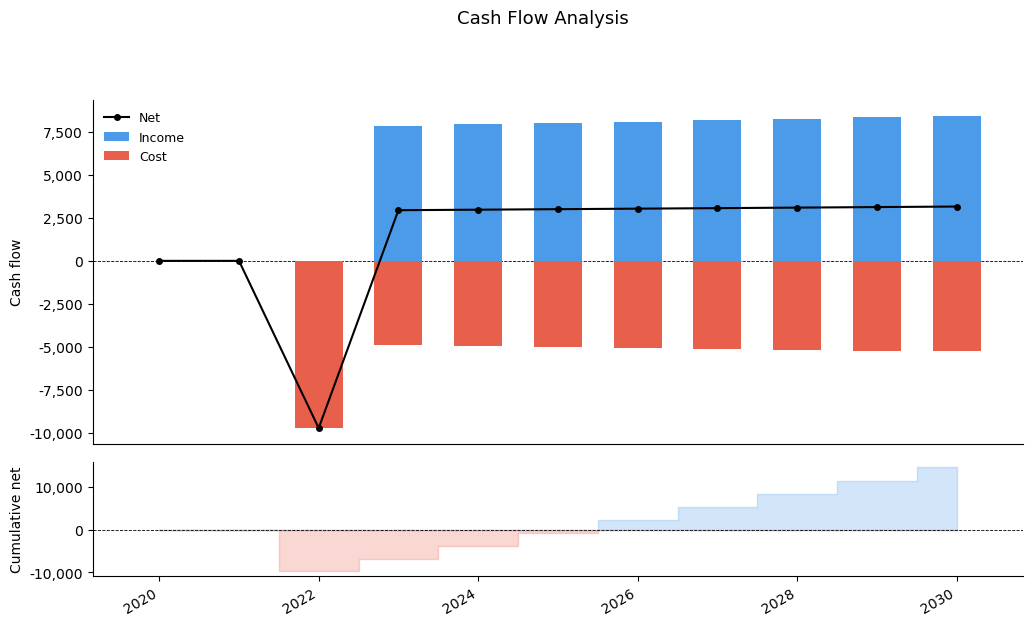

In [1]:
from climada.entity.measures.cost_income import CostIncome

ci = CostIncome(
    mkt_price_year=2025,
    init_cost=10_000,  # 10 000 upfront
    periodic_cost=5_000,  # 5 000 / year maintenance
    periodic_income=8_000,  # 8 000 / year in avoided losses
    cost_yearly_growth_rate=0.01,
    income_yearly_growth_rate=0.01,
    freq="Y",  # annual cash flows
)

impl_date = "2022-01-01"
start_date = "2020-01-01"
end_date = "2030-01-01"


display(ci.to_dataframe(impl_date, start_date, end_date))
ci.plot_cash_flows(impl_date, start_date, end_date)

## Defining a `CostIncome`

The simplest way to create a `CostIncome` is by passing keyword arguments directly.

| Parameter | Meaning |
|---|---|
| `init_cost` | One-off implementation cost |
| `periodic_cost` | Recurring cost each period |
| `periodic_income` | Recurring income each period |
| `mkt_price_year` | Reference year for cost/income growth rates |
| `cost_yearly_growth_rate` | Growth rate for costs |
| `income_yearly_growth_rate` | Growth rate for costs |
| `freq` | Period frequency (e.g. `'Y'` for yearly, `'M'` for monthly, `'Q'` for quaterly) <br> see more [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#period-aliases))

```{note} **Sign convention**
`CostIncome` stores costs as negative numbers internally.
```

```{note}
Financial values in `CostIncome` are currently unitless (no currency is specified)
```

In [2]:
from climada.entity.measures.cost_income import CostIncome

ci = CostIncome(
    mkt_price_year=2025,
    init_cost=10_000,  # 10 000 upfront
    periodic_cost=5_000,  # 5 000 / year maintenance
    periodic_income=8_000,  # 8 000 / year in avoided losses
    cost_yearly_growth_rate=0.01,
    income_yearly_growth_rate=0.01,
    freq="Y",  # annual cash flows
)

## Calculating cash flows

Three methods are available to calculate cash flows:

| Method | Returns |
|---|---|
| `calc_cash_flows(impl_date, start_date, end_date)` | Three `np.ndarray`: net, costs, incomes |
| `calc_total(impl_date, start_date, end_date)` | Three scalars: summed net, cost, income |
| `to_dataframe(impl_date, start_date, end_date)` | A tidy `pd.DataFrame` |

The `impl_date` is when the measure is *deployed*. Cash flows before this date are zero; the initial cost lands on `impl_date`; periodic flows start the following period.

```{note}
Dates should follow the standard format "yyyy-mm-dd" or be an integer representing the year.
```

In [3]:
import pandas as pd

impl_date = "2022-01-01"
start_date = "2020-01-01"
end_date = "2030-01-01"

net, costs, incomes = ci.calc_cash_flows(impl_date, start_date, end_date)
total_net, total_cost, total_income = ci.calc_total(impl_date, start_date, end_date)

print("Period  | Net       | Cost      | Income")
print("-" * 45)
periods = pd.period_range(start=start_date, end=end_date, freq="Y")
for p, n, c, i in zip(periods, net, costs, incomes):
    print(f"{p}  | {n:>9.0f} | {c:>9.0f} | {i:>6.0f}")
print("-" * 45)
print(f"Total net    : {total_net:>10.0f}")
print(f"Total cost   : {total_cost:>10.0f}")
print(f"Total income : {total_income:>10.0f}")
print("-" * 45)

Period  | Net       | Cost      | Income
---------------------------------------------
2020  |         0 |         0 |      0
2021  |         0 |         0 |      0
2022  |     -9706 |     -9706 |      0
2023  |      2941 |     -4901 |   7842
2024  |      2970 |     -4950 |   7921
2025  |      3000 |     -5000 |   8000
2026  |      3030 |     -5050 |   8080
2027  |      3060 |     -5100 |   8161
2028  |      3091 |     -5152 |   8242
2029  |      3122 |     -5203 |   8325
2030  |      3153 |     -5255 |   8408
---------------------------------------------
Total net    :      14662
Total cost   :     -50318
Total income :      64979
---------------------------------------------


In [4]:
ci.to_dataframe(impl_date, start_date, end_date)

,date,net,cost,income
0,2020,0.000000,0.000000,0.000000
1,2021,0.000000,0.000000,0.000000
2,2022,-9705.636889,-9705.636889,0.000000
3,2023,2940.807977,-4901.346629,7842.154606
4,2024,2970.216057,-4950.360095,7920.576152
5,2025,3000.000000,-5000.000000,8000.000000
6,2026,3030.000000,-5050.000000,8080.000000
7,2027,3060.300000,-5100.500000,8160.800000
8,2028,3090.903000,-5151.505000,8242.408000
9,2029,3121.897135,-5203.161892,8325.059028


## Visualising cash flows

`plot_cash_flows` draws a bar chart of the cash flows. The top panel of the plot shows costs, incomes and net values for each period, while the bottom panel shows the cumulated net value.

Figure size and title can be customized directly in the method. The method returns a tuple with the two matplotlib axes objects.

(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

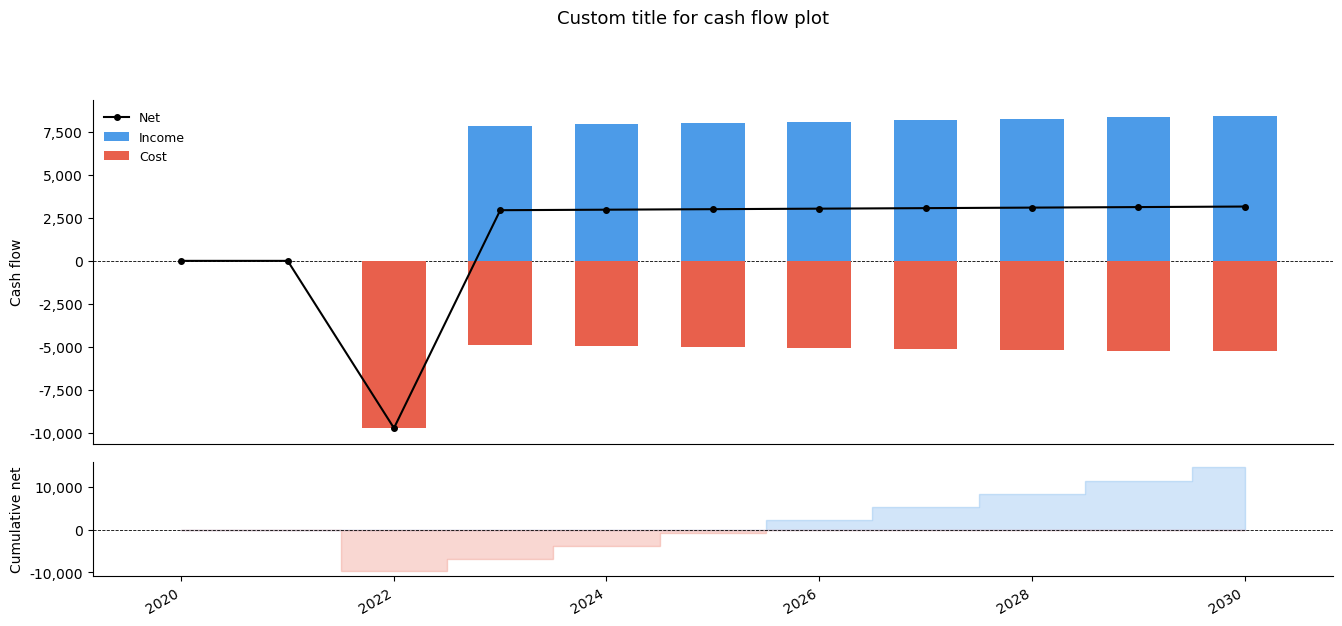

In [5]:
ci.plot_cash_flows(
    impl_date,
    start_date,
    end_date,
    figsize=(16, 7),
    title="Custom title for cash flow plot",
)

## Growth rates

Costs and incomes can grow year-over-year using compound-interest factors anchored to the `mkt_price_year` attribute.

$$\text{value}(t) = \text{base} \times (1 + r)^{\frac{t - t_0}{365}}$$

Pass `cost_yearly_growth_rate` and / or `income_yearly_growth_rate` (as decimals, e.g. `0.02` for 2 %).

(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

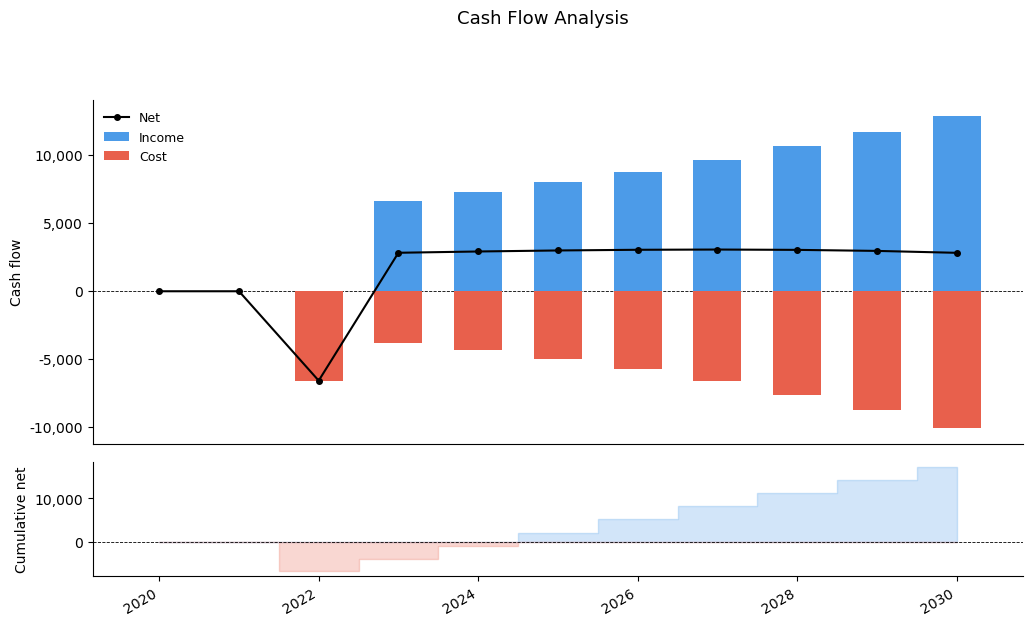

In [6]:
ci_growth = CostIncome(
    mkt_price_year=2025,
    init_cost=10_000,
    periodic_cost=5_000,
    periodic_income=8_000,
    cost_yearly_growth_rate=0.15,
    income_yearly_growth_rate=0.10,
    freq="Y",
)

ci_growth.plot_cash_flows(impl_date, start_date, end_date)

In [7]:
# Compare totals with and without growth
no_growth = ci.calc_total(impl_date, start_date, end_date)
with_growth = ci_growth.calc_total(impl_date, start_date, end_date)

labels = ["Net", "Cost", "Income"]
print(f"{'':15s} {'No growth':>12s} {'With growth':>12s}")
for label, ng, wg in zip(labels, no_growth, with_growth):
    print(f"{label:15s} {ng:>12.0f} {wg:>12.0f}")

                   No growth  With growth
Net                    14662        17138
Cost                  -50318       -58474
Income                 64979        75612


## Custom cash flows

For irregular or one-off flows, pass a `pd.DataFrame` with columns `date`, `cost`, and/or `income`.

These are **added on top** of any periodic amounts; dates not present in the DataFrame simply contribute zero.

In [8]:
custom_flows = pd.DataFrame(
    {
        "date": ["2024-01-01", "2026-01-01", "2028-01-01"],
        "cost": [10_000, 0, 20_000],  # extra one-off costs
        "income": [0, 15_000, 0],  # extra one-off income
    }
)

ci_custom = CostIncome(
    mkt_price_year=2025,
    init_cost=10_000,
    periodic_cost=5_000,
    periodic_income=8_000,
    custom_cash_flows=custom_flows,
    freq="Y",
)
ci_custom.to_dataframe(impl_date, start_date, end_date)

,date,net,cost,income
0,2020,0.0,0.0,0.0
1,2021,0.0,0.0,0.0
2,2022,-10000.0,-10000.0,0.0
3,2023,3000.0,-5000.0,8000.0
4,2024,-7000.0,-15000.0,8000.0
5,2025,3000.0,-5000.0,8000.0
6,2026,18000.0,-5000.0,23000.0
7,2027,3000.0,-5000.0,8000.0
8,2028,-17000.0,-25000.0,8000.0
9,2029,3000.0,-5000.0,8000.0


(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

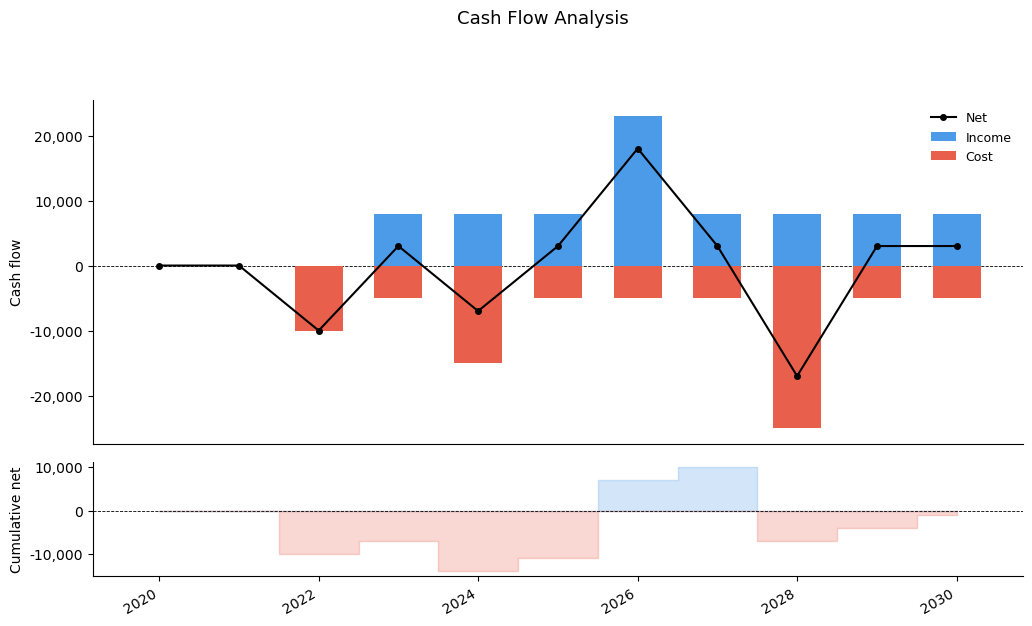

In [9]:
ci_custom.plot_cash_flows(impl_date, start_date, end_date)

## Sub-annual frequencies

`freq` accepts any [pandas-compatible period aliases string](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#period-aliases).

Common options:

| `freq` | Meaning |
|---|---|
| `"Y"` | Annual |
| `"Q"` | Quarterly |
| `"M"` | Monthly |
| `"7D"` | Every 7 days |

```{note}
The periodic amounts are interpreted as **per-period** values. A periodic cost of 500 with a monthly frequency ("M"), means a cost of 500 per month. The growth rates however are always considered to be yearly.
```

```{note}
The implementation, starting and ending dates are coerced to the period frequency. For instance `"2022-01-05"` with monthly frequency is considered as `"2022-01"`.
```

In [10]:
ci_monthly = CostIncome(
    mkt_price_year=2022,
    init_cost=5_000,
    periodic_cost=500,
    periodic_income=700,
    freq="M",
)

df_monthly = ci_monthly.to_dataframe(
    impl_date="2022-01-05",
    start_date="2022-01",
    end_date="2022-12",
)
df_monthly

,date,net,cost,income
0,2022-01,-5000.0,-5000.0,0.0
1,2022-02,200.0,-500.0,700.0
2,2022-03,200.0,-500.0,700.0
3,2022-04,200.0,-500.0,700.0
4,2022-05,200.0,-500.0,700.0
5,2022-06,200.0,-500.0,700.0
6,2022-07,200.0,-500.0,700.0
7,2022-08,200.0,-500.0,700.0
8,2022-09,200.0,-500.0,700.0
9,2022-10,200.0,-500.0,700.0


(<Axes: ylabel='Cash flow'>, <Axes: ylabel='Cumulative net'>)

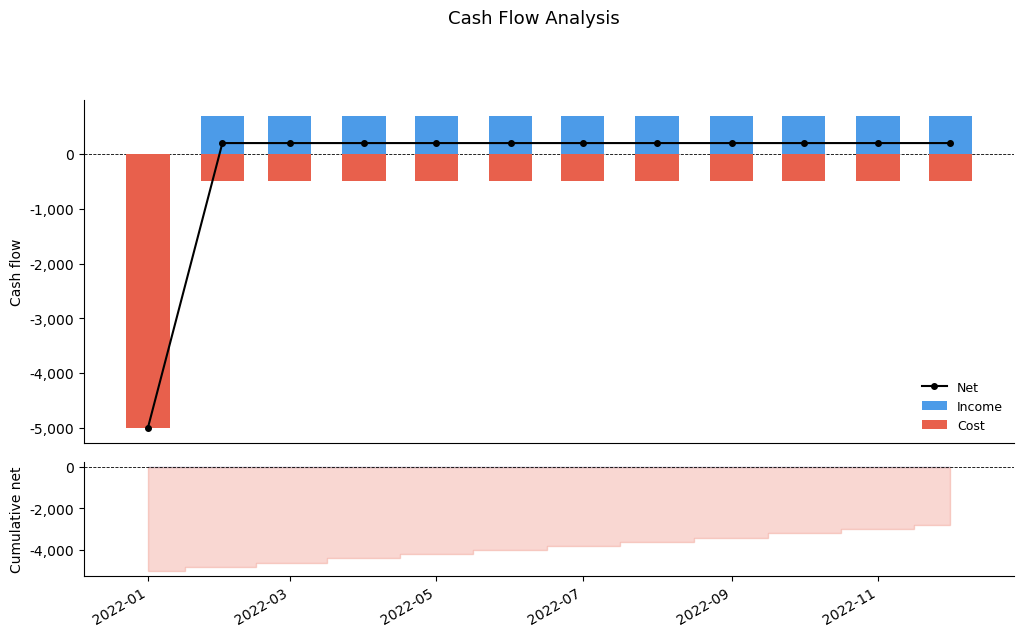

In [11]:
ci_monthly.plot_cash_flows(
    "2022-01",
    "2022-01",
    "2022-12",
)

## Combining multiple CostIncome objects

`CostIncome.comb_cost_income()` aggregates a list of `CostIncome` objects into a single one by summing costs and incomes.

```{warning}
All objects must share the same `mkt_price_year`, `cost_growth_rate`, and `income_growth_rate`.
```

```{note}
`custom_cash_flows` are merged by summing them together.
```

,cost,income
date,,
2022-01-01,-2000,0
2023-01-01,0,0
2024-01-01,-10000,0
2025-01-01,0,0
2026-01-01,0,20000
2027-01-01,0,0
2028-01-01,-20000,0
2029-01-01,-10000,0


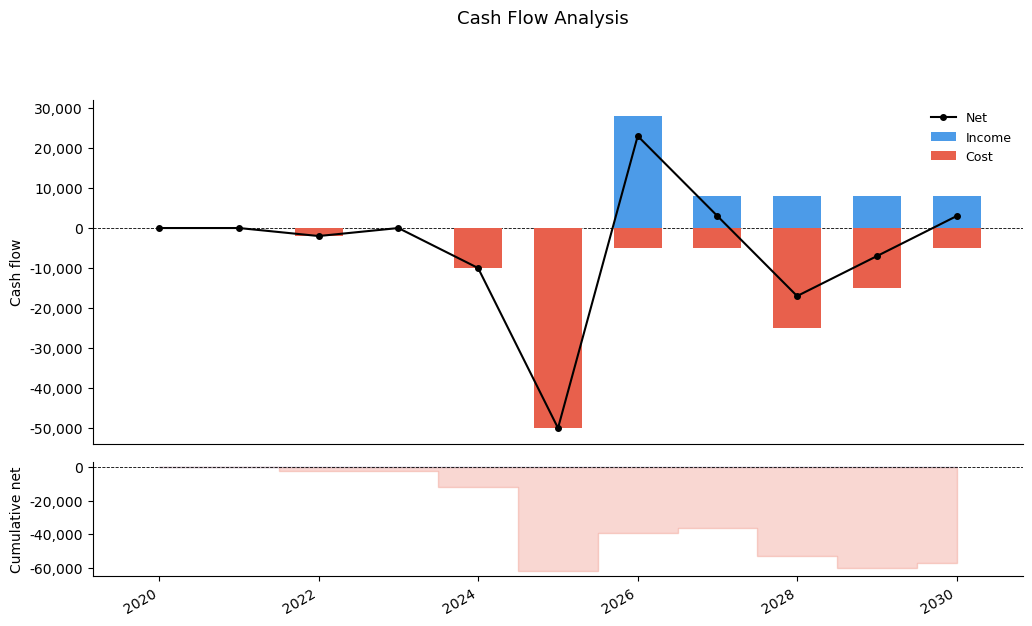

In [12]:
import pandas as pd

custom_flows_a = pd.DataFrame(
    {
        "date": ["2024", "2026", "2028"],
        "cost": [10_000, 0, 20_000],  # extra one-off costs
        "income": [0, 15_000, 0],  # extra one-off income
    }
)

custom_flows_b = pd.DataFrame(
    {
        "date": ["2022", "2026", "2029"],
        "cost": [2_000, 0, 10_000],  # extra one-off costs
        "income": [0, 5_000, 0],  # extra one-off income
    }
)

ci_a = CostIncome(
    mkt_price_year=2020,
    init_cost=30_000,
    periodic_cost=2_000,
    periodic_income=4_000,
    custom_cash_flows=custom_flows_a,
    freq="Y",
)

ci_b = CostIncome(
    mkt_price_year=2020,
    init_cost=20_000,
    periodic_cost=3_000,
    periodic_income=4_000,
    custom_cash_flows=custom_flows_b,
    freq="Y",
)

ci_combined = CostIncome.comb_cost_income([ci_a, ci_b])
ci_combined.plot_cash_flows(
    "2025",
    "2020",
    "2030",
)

ci_combined.custom_cash_flows

## Loading from dict / YAML

### From a Python dictionary

In [13]:
config_dict = {
    "mkt_price_year": 2020,
    "init_cost": 50_000,
    "periodic_cost": 5_000,
    "periodic_income": 8_000,
    "cost_yearly_growth_rate": 0.02,
    "income_yearly_growth_rate": 0.03,
    "freq": "Y",
}

ci_from_dict = CostIncome.from_dict(config_dict)
print(ci_from_dict)

CostIncome(
  mkt_price_year          = 2020
  freq                    = 'Y'
  init_cost               = -50,000.00
  periodic_cost           = -5,000.00
  periodic_income         = 8,000.00
  cost_yearly_growth_rate = 2.00%
  income_yearly_growth_rate = 3.00%
  custom_cash_flows       = None
)


### From a YAML file

Create a YAML file structured as follows, then load it with `CostIncome.from_yaml(<path to file>)`.

```yaml
# measure_cost.yaml
cost_income:
  mkt_price_year: 2020
  init_cost: 50000
  periodic_cost: 5000
  periodic_income: 8000
  cost_yearly_growth_rate: 0.02
  income_yearly_growth_rate: 0.03
  freq: "Y"
  # Optional custom flows:
  # custom_cash_flows:
  #   - date: "2024-01-01"
  #     cost: 10000
  #     income: 0
```

---

```python
# Inside Notebook or script
ci_from_yaml = CostIncome.from_yaml("measure_cost.yaml")
```